# Analyse des cours de Bourse

## Import Librairies

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import yfinance as yf
import datetime

## Exploration des données de la librairie yfinance

In [4]:
# Définir le ticker pour LVMH sur Euronext Paris
ticker = "MC.PA"

# Récupérer les données de l'action
action_suivie = yf.Ticker(ticker)

### Données de base de l'action

In [3]:
action_suivie.info

{'address1': '22, Avenue Montaigne',
 'city': 'Paris',
 'zip': '75008',
 'country': 'France',
 'phone': '33 1 44 13 22 22',
 'fax': '33 1 44 13 22 23',
 'website': 'https://www.lvmh.com',
 'industry': 'Luxury Goods',
 'industryKey': 'luxury-goods',
 'industryDisp': 'Luxury Goods',
 'sector': 'Consumer Cyclical',
 'sectorKey': 'consumer-cyclical',
 'sectorDisp': 'Consumer Cyclical',
 'longBusinessSummary': "LVMH Moët Hennessy - Louis Vuitton, Société Européenne, together with its subsidiaries, operates as a luxury goods company worldwide. It offers wine and spirit products under the Ao Yun, Ardbeg, Armand de Brignac, Belvedere, Bodega Numanthia, Chandon, Cheval des Andes, Château Cheval Blanc, Château Galoupet, Château d'Yquem, Château d'Esclans, Cloudy Bay, Colgin Cellars, Dom Pérignon, Domaine des Lambrays, Eminente, Glenmorangie, Hennessy, Joseph Phelps, Krug, Mercier, Minuty, Moët & Chandon, Newton Vineyard, Ruinart, SirDavis, Terrazas de los Andes, Veuve Clicquot, Volcan de mi Tier

### Données historiques du cours de bourse (.history)

In [4]:
# Récupérer l'historique des 2 dernières années (intervalle de 1 jour)
historique = action_suivie.history(period="2y", interval="1d")
# S'assurer que l'index est trié
historique = historique.sort_index()

# Calcul des indicateurs
historique["prev_close"] = historique["Close"].shift(1)
historique["MA20"] = historique["Close"].rolling(20).mean()
historique["MA50"] = historique["Close"].rolling(50).mean()
historique["support"] = historique["Low"].rolling(50).min()
historique["resistance"] = historique["High"].rolling(50).max()

# Période d'affichage
periode = 365  # jours
df_affiche = historique.loc[historique.index >= historique.index.max() - pd.Timedelta(days=periode)]

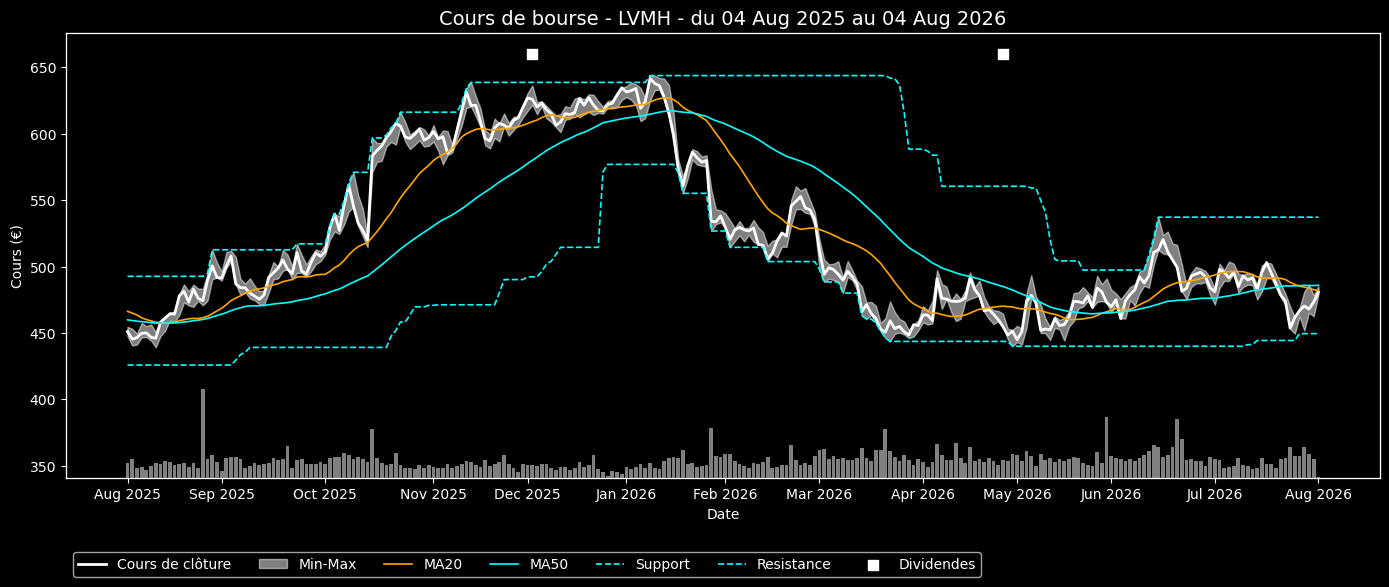

In [12]:
# Création graphique
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(14, 6))
ax.set_title(f"Cours de bourse - {action_suivie.info['shortName']} - du {df_affiche.index.min().date().strftime("%d %b %Y")} au {df_affiche.index.max().date().strftime("%d %b %Y")}", fontsize=14)
# Axe X compressé
x = range(len(df_affiche))

# Cours de cloture
ax.plot(x, df_affiche["Close"], color="white", linewidth=2, label="Cours de clôture")
# Bande High–Low
ax.fill_between(x, df_affiche["Low"], df_affiche["High"],alpha=0.5, color="white", label="Min-Max")
# Moyennes mobiles
ax.plot(x, df_affiche["MA20"], color="orange", linewidth=1.2, label="MA20")
ax.plot(x, df_affiche["MA50"], color="cyan", linewidth=1.2, label="MA50")
# Support / résistance simples
ax.plot(x, df_affiche["support"], color="#00FFFF", linestyle="--", linewidth=1.2, label="Support")
ax.plot(x, df_affiche["resistance"], color="#00FFFF", linestyle="--", linewidth=1.2, label="Resistance")
ax.set_ylim(df_affiche["support"].min() * 0.8, df_affiche["resistance"].max() * 1.05)
# Volume en sous-graphe
ax2 = ax.twinx()
ax2.bar(x, df_affiche["Volume"], color="gray", label="Volume")
ax2.set_ylim(0, df_affiche["Volume"].max() * 5)  # pour ne pas écraser le graphique principal
# Dividendes en sur-graphe
div_non_nuls = df_affiche[df_affiche["Dividends"] > 0]
div_non_nuls = div_non_nuls.copy()
div_non_nuls['DivExist'] = 1
ax3 = ax.twinx()
ax3.scatter(div_non_nuls.index.map(lambda d: df_affiche.index.get_loc(d)), div_non_nuls["DivExist"], marker="s", s=50, color="white", label="Dividendes")
ax3.set_ylim(0, 1.05)

# Finalisation graphique
## Légende
handles1, labels1 = ax.get_legend_handles_labels()
handles3, labels3 = ax3.get_legend_handles_labels()
ax.legend(handles1 + handles3, labels1 + labels3, loc="upper left", bbox_to_anchor=(0, -0.15), ncol=8)
## Axe X : labels de dates début de mois
premiers_jours = df_affiche.groupby([df_affiche.index.year, df_affiche.index.month]).head(1)
ticks = [df_affiche.index.get_loc(d) for d in premiers_jours.index]
ax.set_xticks(ticks)
ax.set_xticklabels(premiers_jours.index.strftime("%b %Y"))
## Etiquettes axes
ax.set_xlabel("Date")
ax.set_ylabel("Cours (€)")
ax2.get_yaxis().set_visible(False)
ax3.get_yaxis().set_visible(False)
plt.tight_layout()
plt.show()

### Données du jour pour le cours de bourse (.history)

In [6]:
# Récupérer l'historique du jour (intervalle de 1 minute)
day_vue = action_suivie.history(period="1d", interval="1m")

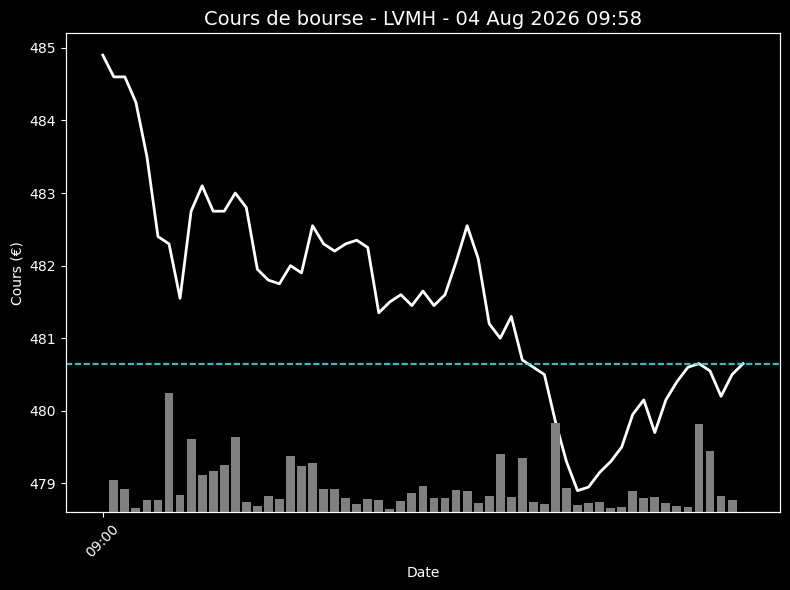

In [7]:
# Création graphique
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(8, 6))
ax.set_title(f"Cours de bourse - {action_suivie.info['shortName']} - {day_vue.index.max().strftime("%d %b %Y %H:%M")}", fontsize=14)
# Axe X compressé
x = range(len(day_vue))
# Cours de cloture
ax.plot(x, day_vue["Close"], color="white", linewidth=2, label="Cours de clôture")
# Cours actuel
ax.axhline(day_vue["Close"].iloc[-1], color="#00FFFF", linestyle="--", linewidth=1.2, label="Support")
# Volume en sous-graphe
ax2 = ax.twinx()
ax2.bar(x, day_vue["Volume"], color="gray", label="Volume")
ax2.set_ylim(0, day_vue["Volume"].max() * 4)  # pour ne pas écraser le graphique principal
# Axe X : labels de dates
ax.set_xticks(x[::60])
ax.set_xticklabels(day_vue.index[::60].strftime("%H:%M"), rotation=45)
# Finalisation graphique
ax.set_xlabel("Date")
ax.set_ylabel("Cours (€)")
ax2.get_yaxis().set_visible(False)
plt.tight_layout()
plt.show()

### Données de dividendes

In [8]:
for k in ['currency','lastDividendValue','lastDividendDate']:
    if isinstance(action_suivie.info.get(k), int):
        value = datetime.datetime.fromtimestamp(action_suivie.info.get(k))
    else:
        value = action_suivie.info.get(k)
    print(f"{k:25} : {value}")

currency                  : EUR
lastDividendValue         : 5.5
lastDividendDate          : 2026-12-01 01:00:00


### Calcul de données annuelles

In [9]:
un_an = historique.index.max() - pd.Timedelta(days=365)
historique_1an = historique.loc[historique.index >= un_an]
# Cours historique moyen
cours_moyen_1an = historique_1an['Close'].mean()
print("Cours moyen :", cours_moyen_1an)
# Dividendes versés sur l'année
dividendes_1an = historique_1an['Dividends'].sum()
print("Dividendes :", dividendes_1an)
# Rendement dividendes / cours moyen
if cours_moyen_1an != 0:
    ratio_div_1an = dividendes_1an * 100 / cours_moyen_1an
else:
    ratio_div_1an = 0
print("Ratio Div %:", ratio_div_1an)
# Rendement du cours sur 1 an
prix_initial = historique_1an['Close'].iloc[0]
prix_final = historique_1an['Close'].iloc[-1]
if prix_initial != 0:
    rendement_1an = (prix_final / prix_initial) - 1
else:
    rendement_1an = 0
print("Rendement % :", rendement_1an * 100)
# Volatilité (Volatilité 10 % → actif stable, Volatilité 20–30 % → actif “normal”, Volatilité > 40 % → actif très risqué)
rendements = historique_1an['Close'].pct_change().dropna() # calcul des rendements journaliers
volatilite_1an = rendements.std() * (252 ** 0.5)
print("Volatilité % :", volatilite_1an * 100)

Cours moyen : 522.1048117810346
Dividendes : 13.0
Ratio Div %: 2.4899215074562586
Rendement % : 6.576665087521438
Volatilité % : 30.502880869359068


### Analystes et recommandations

In [6]:
# Objectifs de cours
print(action_suivie.analyst_price_targets)
action_suivie.analyst_price_targets['current']


{'current': 480.0, 'high': 660.0, 'low': 420.0, 'mean': 569.5423, 'median': 580.0}


480.0

In [18]:
# Recommandations
action_suivie.recommendations

,period,strongBuy,buy,hold,sell,strongSell
0,0m,5,12,9,0,0
1,-1m,5,11,9,0,0
2,-2m,5,12,9,0,0
3,-3m,5,13,9,0,0


In [19]:
# Prévisions de Bénéfice par action (EPS)
# 0q = trimestre en cours, +1q = trimestre suivant, 0y = année en cours, 1+y = année suivante
# EPS estimé (avg=moyen, low=pessimiste, high=optimiste), EPS réel année précédente, Croissance estimée
action_suivie.earnings_estimate

,avg,low,high,yearAgoEps,numberOfAnalysts,growth,currency
period,,,,,,,
0q,NaN,NaN,NaN,NaN,NaN,NaN,EUR
+1q,NaN,NaN,NaN,NaN,NaN,NaN,EUR
0y,22.46006,21.35,23.38825,21.85000,14.0,0.0279,EUR
+1y,25.57904,22.47,30.52000,22.46006,16.0,0.1389,EUR


In [20]:
# Prévisions de Chiffre d'affaires
# 0q = trimestre en cours, +1q = trimestre suivant, 0y = année en cours, 1+y = année suivante
# CA estimé (avg=moyen, low=pessimiste, high=optimiste), CA réel année précédente, Croissance estimée
action_suivie.revenue_estimate

,avg,low,high,numberOfAnalysts,yearAgoRevenue,growth,currency
period,,,,,,,
0q,18708500000,18520000000,18897000000,2,18280000000,0.0234,EUR
+1q,23425500000,23317000000,23534000000,2,22717000000,0.0312,EUR
0y,80968294910,79993000000,83260000000,20,80807000000,0.0020,EUR
+1y,85315038910,83087000000,90724000000,22,80968294910,0.0537,EUR
